In [1]:
coords = [
         '08 05 26 -39 08 54',
         '08 26 34 -50 39 54',
         '09 26 19 -45 11 0',
         '09 28 47 -51 36 42',
         '10 49 00 -62 23 06',
         '11 07 07 -62 05 48',
         '12 22 09 -66 27 06',
         '12 24 13 -66 10 42',
         '15 42 20 -52 49 06',
         '16 12 43 -52 15 36',
         '16 06 18 -45 55 18',
         '16 58 42 -50 35 48',
         '16 04 29 -39 37 48',
         '16 46 45 -44 30 48',
         '17 19 36 -43 27 06',
         '17 20 45 -43 20 30',
         '17 22 55 -43 22 36',
         '16 37 28 -35 13 54',
         '17 48 01 -43 43 12',
         '17 04 26 -36 18 48',
         '17 04 27 -36 08 24'
         ]

full_list = [16,34,44,53,58,59,74,75,111,113,117,121,126,133,138,139,140,144,145,148,149]

In [1]:
from astroquery.vizier import Vizier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
import scipy
from astropy.wcs import WCS
from astropy.io import fits

In [3]:
v = Vizier(columns=["*", "+_r"], catalog="2MASS")
result1 = v.query_region('15 42 57.11 -52 45 16.16', radius="10s")
result1

Empty TableList

In [4]:
v.ROW_LIMIT = -1

967


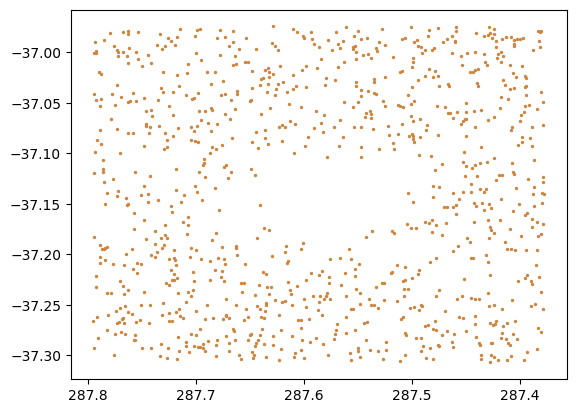

Done


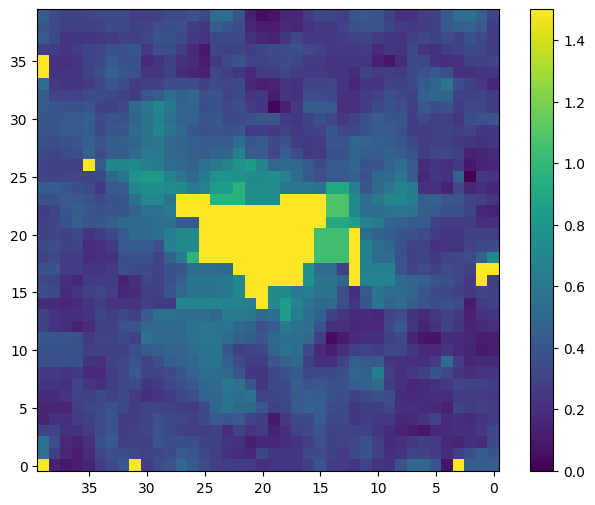

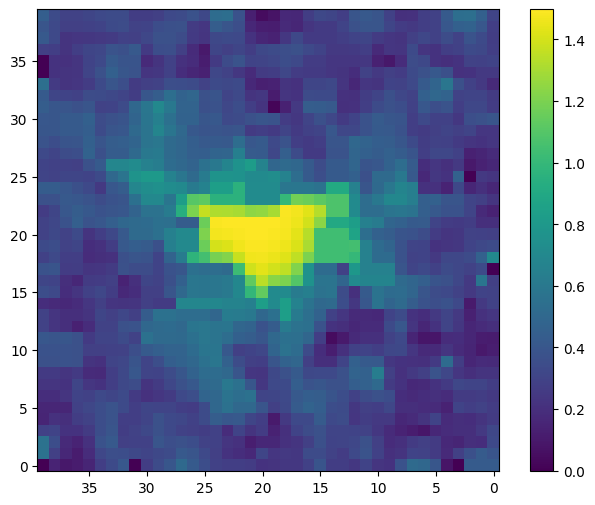

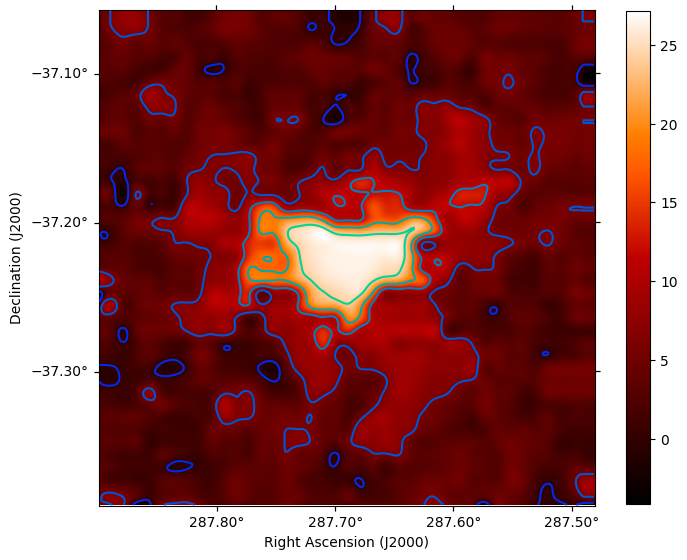

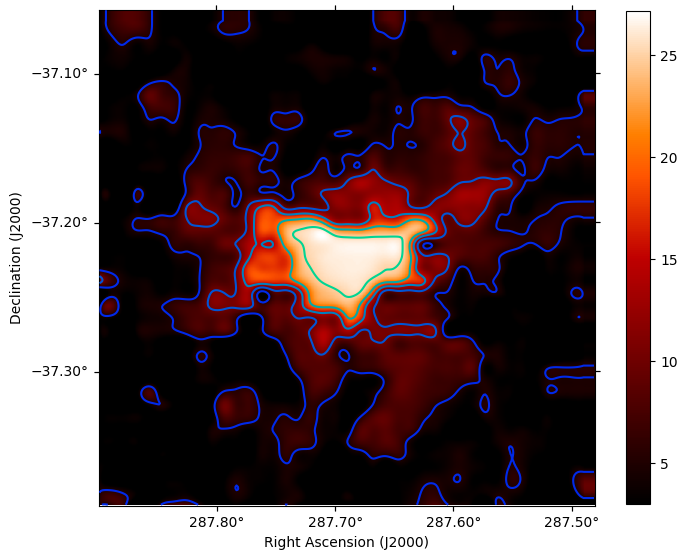

In [12]:
a = 3

coord = '17 22 38.2 -23 49 34'

s = [float(i) for i in coord.split()]
ra = s[0]*15 + s[1]/4 + s[2]/240
dec = s[3] - s[4]/60 - s[5]/3600

ra, dec = 287.5857417, -37.1408333 

result = v.query_region(str(ra) + ' ' + str(dec), width = "20m")
r = result[0]
r = r.to_pandas()
r=r.dropna()
print(len(r))

plt.scatter(r['RAJ2000'], r['DEJ2000'], s = 2, color = 'peru')
plt.gca().invert_xaxis()
plt.show()




b = 1/120
f = 3

if 1:
    cenra = np.arange(np.min(r['RAJ2000']), np.max(r['RAJ2000']), b/np.cos(dec*np.pi/180))
    cendec = np.arange(np.min(r['DEJ2000']), np.max(r['DEJ2000']), b)

    m = np.zeros((len(cendec), len(cenra)))

    for i in range(len(cendec)):
        for j in range(len(cenra)):
            ra0 = cenra[j]
            dec0 = cendec[i]

            mask = (np.abs(r['RAJ2000'] - ra0) < f*b/2/np.cos(dec*np.pi/180)) & (np.abs(r['DEJ2000'] - dec0) < f*b/2)

            new = r[mask]
            
            if len(new) != 0:
                av = np.mean(new['Hmag'] - new['Kmag'])
            else:
                av = 1.5

            m[i][-j-1] = av
     
    print('Done')
    plt.figure(figsize = (8,6))
    plt.imshow(m)
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    plt.colorbar()
    plt.show()

    for i in range(len(cendec)):
        for j in range(len(cenra)):
            if m[i][j] == 1.5:
                m[i][j] = np.sum(m[i-1:i,j:j+1] + m[i+1:i+2,j:j+1] + m[i:i+1,j-1:j] + m[i:i+1,j+1:j+2]) / 4
                #print(m[i-1:i][j:j+1])
                
    plt.figure(figsize = (8,6))
    plt.imshow(m)
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    plt.colorbar()
    plt.show()
    
    

k = 0.0

n = scipy.ndimage.gaussian_filter(m, [k,k], mode='constant')


f = scipy.interpolate.RectBivariateSpline(cenra, cendec, n)

bnew = 0.001
newra = np.arange(np.min(r['RAJ2000']), np.max(r['RAJ2000']), bnew/np.cos(dec*np.pi/180))
newdec = np.arange(np.min(r['DEJ2000']), np.max(r['DEJ2000']), bnew)

p = f(newra, newdec)

w = WCS(naxis = 2)
w.wcs.crpix = [30*b/bnew,30*b/bnew]
w.wcs.cdelt = np.array([-bnew, bnew])
w.wcs.crval = [ra, dec]
w.wcs.ctype = ["RA---TAN", "DEC--TAN"]
w.wcs.set_pv([(2, 1, 45.0)])

fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(111, projection=w)

p = 19.4*(p-0.13)

im = ax.imshow(p, origin='lower', cmap='gist_heat')#, vmin = 0.1, vmax = 100)

ax.coords[0].set_major_formatter('d.dd')
ax.coords[1].set_major_formatter('d.dd')
ax.coords[0].set_axislabel('Right Ascension (J2000)')
ax.coords[1].set_axislabel('Declination (J2000)')

# Show the plot
fig.colorbar(im, ax = ax, shrink = 0.8, location = 'right')
plt.contour(p, levels = 5, cmap = 'winter')
plt.show()


fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(111, projection=w)

pn = np.clip(p, 3, 30)
im = ax.imshow(pn, origin='lower', cmap='gist_heat')#, vmin = 0.1, vmax = 100)

ax.coords[0].set_major_formatter('d.dd')
ax.coords[1].set_major_formatter('d.dd')
ax.coords[0].set_axislabel('Right Ascension (J2000)')
ax.coords[1].set_axislabel('Declination (J2000)')

# Show the plot
fig.colorbar(im, ax = ax, shrink = 0.8, location = 'right')
plt.contour(pn, levels = 5, cmap = 'winter')
plt.show()

# Older:

In [10]:
h = w.to_header()
hdu = fits.PrimaryHDU(data = p, header=h)

hdu.writeto('2MASS Maps/B68_lowres.fits')#.format(full_list[a]), overwrite=True)

121


5323


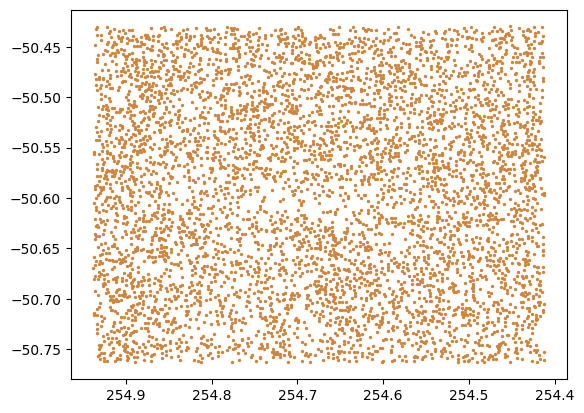

Done


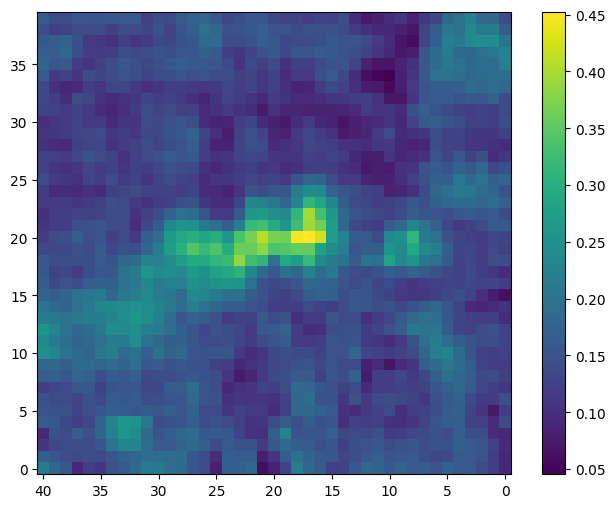

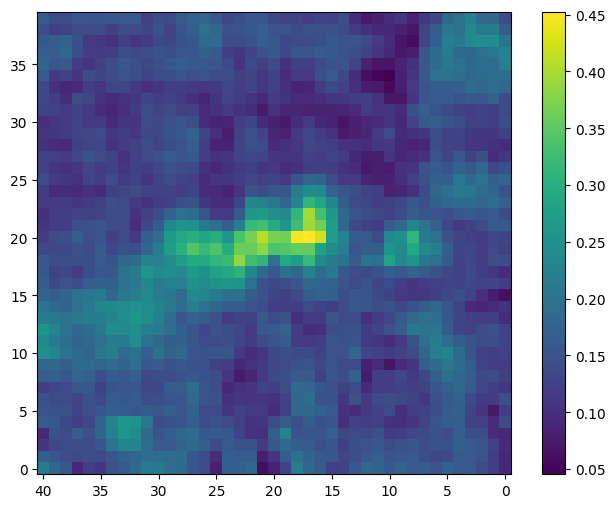

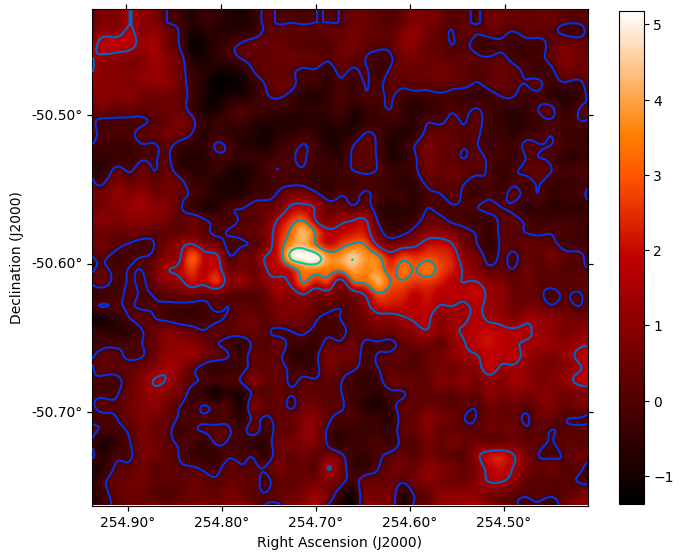

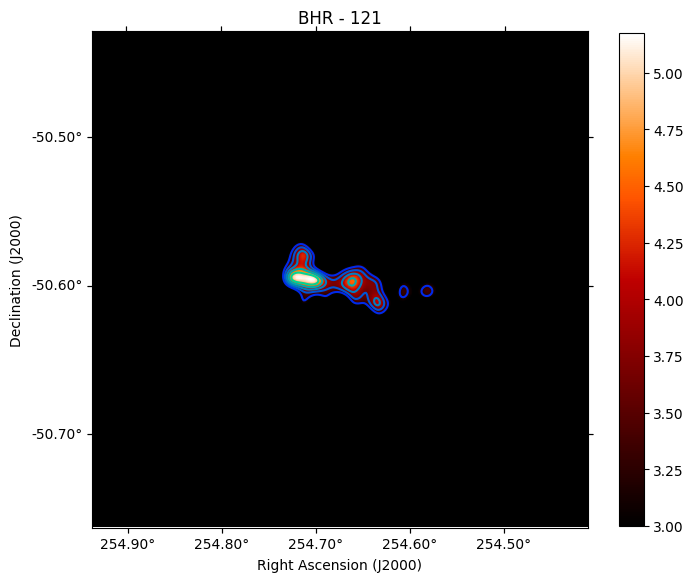

In [8]:
for a in range(11,12):
    print(full_list[a])
    coord = coords[a]

    s = [float(i) for i in coord.split()]
    ra = s[0]*15 + s[1]/4 + s[2]/240
    dec = s[3] - s[4]/60 - s[5]/3600

    result = v.query_region(str(ra) + ' ' + str(dec), width = "20m")
    r = result[0]
    r = r.to_pandas()
    r=r.dropna()
    print(len(r))

    plt.scatter(r['RAJ2000'], r['DEJ2000'], s = 2, color = 'peru')
    plt.gca().invert_xaxis()
    plt.show()




    b = 1/120
    f = 3


    cenra = np.arange(np.min(r['RAJ2000']), np.max(r['RAJ2000']), b/np.cos(dec*np.pi/180))
    cendec = np.arange(np.min(r['DEJ2000']), np.max(r['DEJ2000']), b)

    m = np.zeros((len(cendec), len(cenra)))

    for i in range(len(cendec)):
        for j in range(len(cenra)):
            ra0 = cenra[j]
            dec0 = cendec[i]

            mask = (np.abs(r['RAJ2000'] - ra0) < f*b/2/np.cos(dec*np.pi/180)) & (np.abs(r['DEJ2000'] - dec0) < f*b/2)

            new = r[mask]
            
            if len(new) != 0:
                av = np.mean(new['Hmag'] - new['Kmag'])
            else:
                av = 1.5

            m[i][-j-1] = av
     
    print('Done')
    plt.figure(figsize = (8,6))
    plt.imshow(m)
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    plt.colorbar()
    plt.show()

    for i in range(len(cendec)):
        for j in range(len(cenra)):
            if m[i][j] == 1.5:
                m[i][j] = np.sum(m[i-1:i,j:j+1] + m[i+1:i+2,j:j+1] + m[i:i+1,j-1:j] + m[i:i+1,j+1:j+2]) / 4
                #print(m[i-1:i][j:j+1])
                
    plt.figure(figsize = (8,6))
    plt.imshow(m)
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    plt.colorbar()
    plt.show()
    
    

    k = 0.0

    n = scipy.ndimage.gaussian_filter(m, [k,k], mode='constant')


    f = scipy.interpolate.interp2d(cenra, cendec, n, kind = 'cubic')

    bnew = 0.001
    newra = np.arange(np.min(r['RAJ2000']), np.max(r['RAJ2000']), bnew/np.cos(dec*np.pi/180))
    newdec = np.arange(np.min(r['DEJ2000']), np.max(r['DEJ2000']), bnew)

    p = f(newra, newdec)

    w = WCS(naxis = 2)
    w.wcs.crpix = [int(len(newra)/2), int(len(newdec)/2)]
    w.wcs.cdelt = np.array([-bnew, bnew])
    w.wcs.crval = [ra, dec]
    w.wcs.ctype = ["RA---TAN", "DEC--TAN"]
    w.wcs.set_pv([(2, 1, 45.0)])

    fig = plt.figure(figsize = (8,8))
    ax = fig.add_subplot(111, projection=w)

    p = 15.9*(p-0.13)

    im = ax.imshow(p, origin='lower', cmap='gist_heat')#, vmin = 0.1, vmax = 100)

    ax.coords[0].set_major_formatter('d.dd')
    ax.coords[1].set_major_formatter('d.dd')
    ax.coords[0].set_axislabel('Right Ascension (J2000)')
    ax.coords[1].set_axislabel('Declination (J2000)')

    # Show the plot
    fig.colorbar(im, ax = ax, shrink = 0.8, location = 'right')
    plt.contour(p, levels = 5, cmap = 'winter')
    plt.show()


    fig = plt.figure(figsize = (8,8))
    ax = fig.add_subplot(111, projection=w)

    pn = np.clip(p, 3, 30)
    im = ax.imshow(pn, origin='lower', cmap='gist_heat')#, vmin = 0.1, vmax = 100)

    ax.coords[0].set_major_formatter('d.dd')
    ax.coords[1].set_major_formatter('d.dd')
    ax.coords[0].set_axislabel('Right Ascension (J2000)')
    ax.coords[1].set_axislabel('Declination (J2000)')

    # Show the plot
    fig.colorbar(im, ax = ax, shrink = 0.8, location = 'right')
    plt.contour(pn, levels = 5, cmap = 'winter')
    plt.title('BHR - {}'.format(full_list[a]))
    plt.show()


    h = w.to_header()
    hdu = fits.PrimaryHDU(data = p, header=h)

    hdu.writeto('2MASS Maps/BHR_{}_lowres.fits'.format(full_list[a]), overwrite=True)

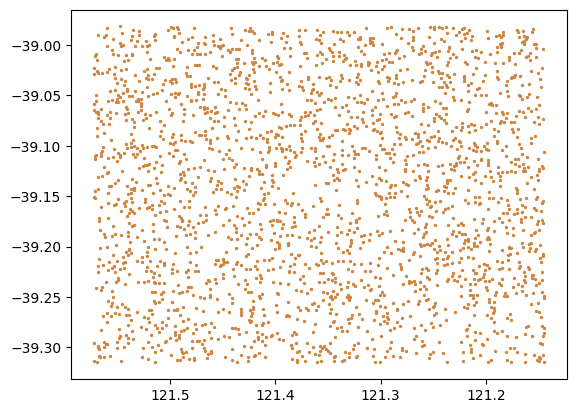

In [8]:
plt.scatter(r['RAJ2000'], r['DEJ2000'], s = 2, color = 'peru')
plt.gca().invert_xaxis()
plt.show()

In [71]:
r = r.to_pandas()
r = r.dropna()
len(r)

5333

Done


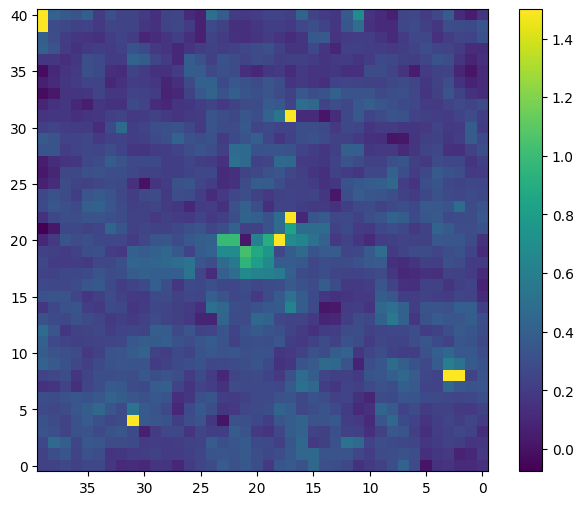

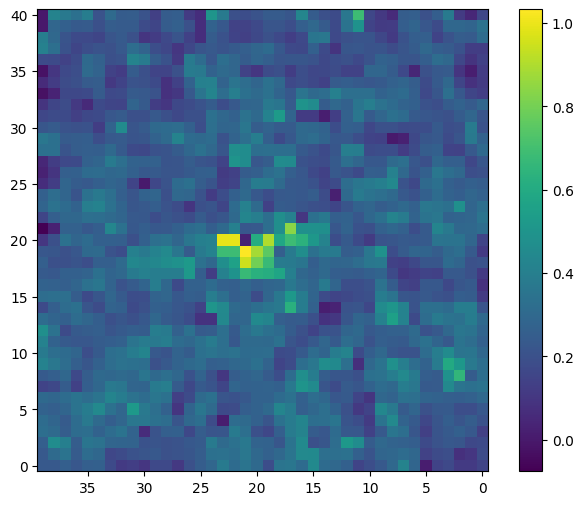

In [9]:
b = 1/120
f = 2

if 1:
    cenra = np.arange(np.min(r['RAJ2000']), np.max(r['RAJ2000']), b/np.cos(dec*np.pi/180))
    cendec = np.arange(np.min(r['DEJ2000']), np.max(r['DEJ2000']), b)

    m = np.zeros((len(cendec), len(cenra)))

    for i in range(len(cendec)):
        for j in range(len(cenra)):
            ra0 = cenra[j]
            dec0 = cendec[i]

            mask = (np.abs(r['RAJ2000'] - ra0) < f*b/2/np.cos(dec*np.pi/180)) & (np.abs(r['DEJ2000'] - dec0) < f*b/2)

            new = r[mask]
            
            if len(new) != 0:
                av = np.mean(new['Hmag'] - new['Kmag'])
            else:
                av = 1.5

            m[i][-j-1] = av
     
    print('Done')
    plt.figure(figsize = (8,6))
    plt.imshow(m)
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    plt.colorbar()
    plt.show()

    for i in range(len(cendec)):
        for j in range(len(cenra)):
            if m[i][j] == 1.5:
                m[i][j] = np.sum(m[i-1:i,j:j+1] + m[i+1:i+2,j:j+1] + m[i:i+1,j-1:j] + m[i:i+1,j+1:j+2]) / 4
                #print(m[i-1:i][j:j+1])
                
    plt.figure(figsize = (8,6))
    plt.imshow(m)
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    plt.colorbar()
    plt.show()

In [99]:
b = [1,2,3,4,5,6]
m[1:2,3:4]

array([[0.18900044]])

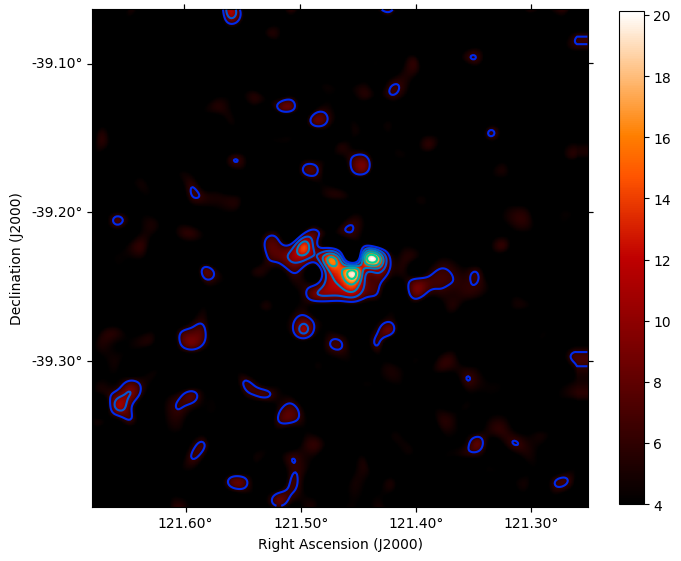

In [11]:
k = 0.0

n = scipy.ndimage.gaussian_filter(m, [k,k], mode='constant')


f = scipy.interpolate.interp2d(cenra, cendec, n, kind = 'cubic')

bnew = 0.001
newra = np.arange(np.min(r['RAJ2000']), np.max(r['RAJ2000']), bnew/np.cos(dec*np.pi/180))
newdec = np.arange(np.min(r['DEJ2000']), np.max(r['DEJ2000']), bnew)

p = f(newra, newdec)

w = WCS(naxis = 2)
w.wcs.crpix = [30*b/bnew,30*b/bnew]
w.wcs.cdelt = np.array([-bnew, bnew])
w.wcs.crval = [ra, dec]
w.wcs.ctype = ["RA---TAN", "DEC--TAN"]
w.wcs.set_pv([(2, 1, 45.0)])

fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(111, projection=w)

p = 19.4*(p-0.13)
pn = np.clip(p, 4, 30)
im = ax.imshow(pn, origin='lower', cmap='gist_heat')#, vmin = 0.1, vmax = 100)

ax.coords[0].set_major_formatter('d.dd')
ax.coords[1].set_major_formatter('d.dd')
ax.coords[0].set_axislabel('Right Ascension (J2000)')
ax.coords[1].set_axislabel('Declination (J2000)')

# Show the plot
fig.colorbar(im, ax = ax, shrink = 0.8, location = 'right')
plt.contour(pn, levels = 5, cmap = 'winter')
plt.show()

In [15]:
h = w.to_header()
hdu = fits.PrimaryHDU(data = p, header=h)

hdu.writeto('2MASS Maps/BHR_{}_2MASS.fits'.format(full_list[a]))